<a href="https://www.kaggle.com/code/taraskin5201/hw2-3-dataset?scriptVersionId=296756553" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [17]:
import os

Ознайомитись з даними та структурою даних

In [18]:
data_dir = '/kaggle/input/fruit-recognition/train/train'

# Перевіряємо класи
classes = os.listdir(data_dir)
print("Класи:", classes)

# Кількість зображень у кожному класі
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    num_images = len(os.listdir(cls_path))
    print(f"{cls}: {num_images} зображень")

Класи: ['Orange', 'Tomato', 'Passion Fruit', 'Cucumber Ripe', 'Cactus fruit', 'Pomegranate', 'Plum', 'Pineapple', 'Papaya', 'Potato Red', 'Kiwi', 'Limes', 'Apple Braeburn', 'Pear', 'Onion White', 'Strawberry', 'Grape Blue', 'Blueberry', 'Apple Granny Smith', 'Apricot', 'Pepper Red', 'Clementine', 'Lemon', 'Avocado', 'Raspberry', 'Cantaloupe', 'Peach', 'Corn', 'Banana', 'Cherry', 'Pepper Green', 'Watermelon', 'Mango']
Orange: 479 зображень
Tomato: 738 зображень
Passion Fruit: 490 зображень
Cucumber Ripe: 392 зображень
Cactus fruit: 490 зображень
Pomegranate: 492 зображень
Plum: 447 зображень
Pineapple: 490 зображень
Papaya: 492 зображень
Potato Red: 450 зображень
Kiwi: 466 зображень
Limes: 490 зображень
Apple Braeburn: 492 зображень
Pear: 696 зображень
Onion White: 438 зображень
Strawberry: 492 зображень
Grape Blue: 984 зображень
Blueberry: 462 зображень
Apple Granny Smith: 492 зображень
Apricot: 492 зображень
Pepper Red: 666 зображень
Clementine: 490 зображень
Lemon: 492 зображень
Avoc

Створіть доповнення(transform) для тренувальних та тестових даних.

In [19]:
# from torchvision import transforms

# # Трансформації для тренувальних даних 
# train_transform = transforms.Compose([
#     transforms.Resize((128, 128)),  # змінюємо розмір
#     transforms.ToTensor()           # перетворюємо у тензор
# ])

# # Трансформації для тестових даних
# test_transform = transforms.Compose([
#     transforms.Resize((128, 128)),
#     transforms.ToTensor()
# ])


from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])


Створіть train_dataset та test_dataset за допомогою ImageFolder(папка train)

In [20]:
import torch
from torch.utils.data import random_split
from torchvision import datasets

In [21]:
data_dir = '/kaggle/input/fruit-recognition/train/train'

dataset = datasets.ImageFolder(
    root=data_dir,
    transform=train_transform
)
    
# Перевіримо класи
print("Класи:", dataset.classes)
print("Загальна кількість зображень:", len(dataset))


Класи: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']
Загальна кількість зображень: 16854


In [22]:
# Визначаємо розміри
total_size = len(dataset)
train_size = int(0.8 * total_size)  # 80% для тренування
test_size = total_size - train_size # 20% для тесту

# Розділяємо dataset
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")


Train size: 13483, Test size: 3371


Переконайтесь що у вас привильні назви класів

In [23]:
print("Назви класів у train_dataset:", dataset.classes)
print("Назви класів у test_dataset:", dataset.classes)


Назви класів у train_dataset: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']
Назви класів у test_dataset: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']


Створіть DataLoader для тренувальних та тестових даних

In [24]:
from torch.utils.data import DataLoader


In [25]:
# Параметри
batch_size = 32  

# DataLoader для тренувальних даних
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# DataLoader для тестових даних
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


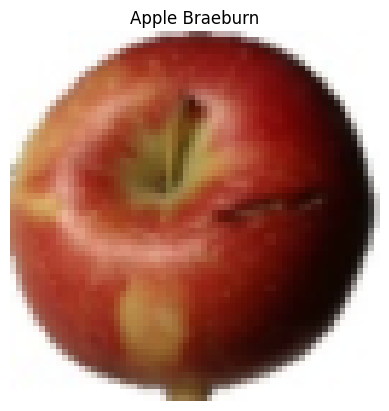

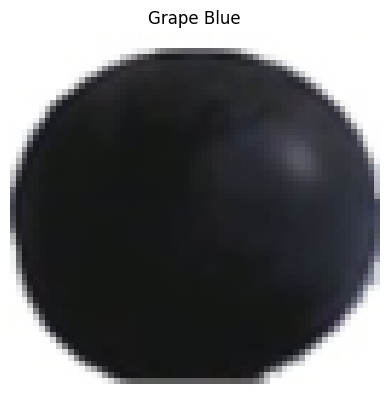

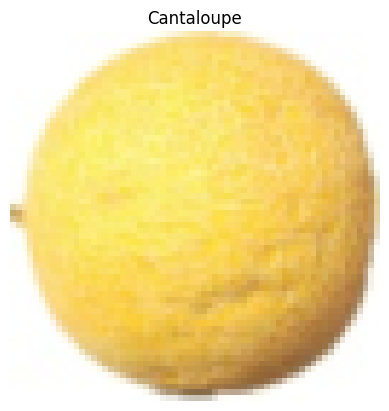

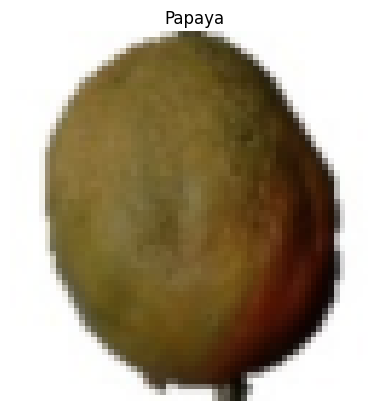

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img, title):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)

for i in range(4):
    imshow(images[i], title=dataset.classes[labels[i]])



На основі train_dataset та test_dataset з попереднього завдання створити train_loader та test_loader

In [27]:

batch_size = 32

# DataLoader для тренувальних даних
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# DataLoader для тестових даних
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Перевіримо кількість батчів
print(f"Кількість батчів у train_loader: {len(train_loader)}")
print(f"Кількість батчів у test_loader: {len(test_loader)}")


Кількість батчів у train_loader: 422
Кількість батчів у test_loader: 106


Створити нейромережу:

використайте 3-5 шари

перший шар Flatten

кількість нейронів у шарах має не збільшуватись

використайте функції активації RELU або LeakyRELU

In [28]:
import torch
import torch.nn as nn

In [29]:
# model = nn.Sequential(
#     nn.Flatten(),                
#     nn.Linear(128*128*3, 1024), 
#     nn.ReLU(),
#     nn.Linear(1024, 512),       
#     nn.ReLU(),
#     nn.Linear(512, 256),        
#     nn.ReLU(),
#     nn.Linear(256, 33)          
# )

num_classes = len(dataset.classes)

model = nn.Sequential(
    nn.Conv2d(3, 8, kernel_size=3, padding='same'),   # 8 × 64 × 64
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                               # 8 × 32 × 32

    nn.Conv2d(8, 16, kernel_size=3, padding='same'),  # 16 × 32 × 32
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                               # 16 × 16 × 16

    nn.Conv2d(16, 32, kernel_size=3, padding='same'), # 32 × 16 × 16
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                               # 32 × 8 × 8

    nn.Flatten(),                                     # 32*8*8 = 2048
    nn.Linear(2048, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("Device:", device)


Device: cpu


In [30]:
import torch
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

loss_list = []
loss_test_list = []

epochs = 10

for i in range(epochs):
    print(f"\nEpoch {i+1}")

    # ===== TRAIN =====
    model.train()
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        result = model(imgs)
        loss = loss_fn(result, labels)
        print(f"train loss: {loss.item()}")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.cpu().item())

    # ===== TEST =====
    model.eval()
    with torch.no_grad():   
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            result = model(imgs)
            loss = loss_fn(result, labels)
            print(f"test loss: {loss.item()}")

            loss_test_list.append(loss.cpu().item())



Epoch 1
train loss: 3.4931557178497314
train loss: 3.4952571392059326
train loss: 3.504828929901123
train loss: 3.506563186645508
train loss: 3.5003974437713623
train loss: 3.4884212017059326
train loss: 3.493987798690796
train loss: 3.4668221473693848
train loss: 3.4702670574188232
train loss: 3.4990017414093018
train loss: 3.5121066570281982
train loss: 3.486750602722168
train loss: 3.464414596557617
train loss: 3.4846527576446533
train loss: 3.4677927494049072
train loss: 3.5310003757476807
train loss: 3.463252067565918
train loss: 3.4518187046051025
train loss: 3.51627254486084
train loss: 3.499711275100708
train loss: 3.459122896194458
train loss: 3.438556671142578
train loss: 3.387327194213867
train loss: 3.4574403762817383
train loss: 3.5250232219696045
train loss: 3.4695119857788086
train loss: 3.4722204208374023
train loss: 3.4186012744903564
train loss: 3.455113172531128
train loss: 3.424067497253418
train loss: 3.461826801300049
train loss: 3.3227250576019287
train loss: 3.

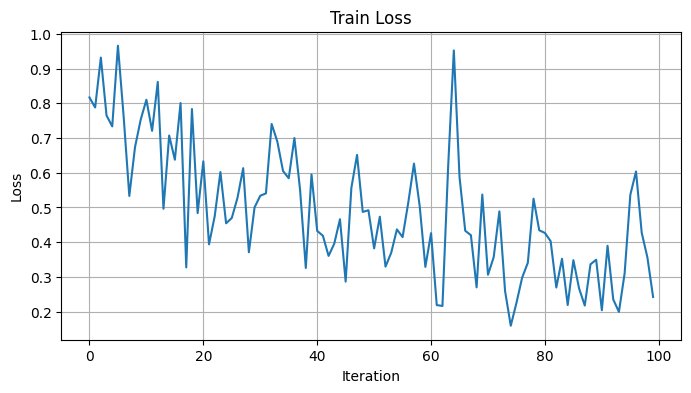

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_list[150:250])
plt.title("Train Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()


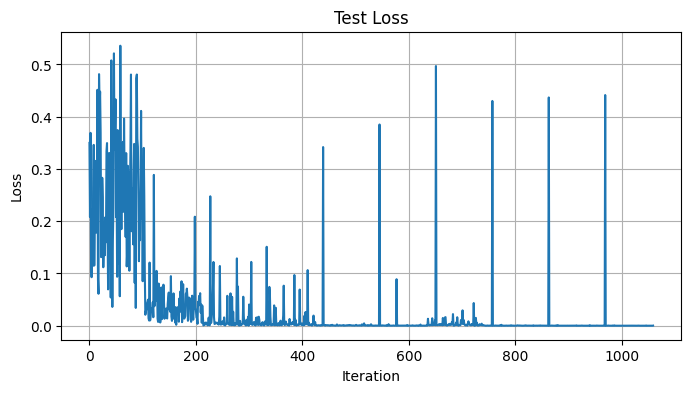

In [32]:
plt.figure(figsize=(8, 4))
plt.plot(loss_test_list)
plt.title("Test Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.show()


Confusion Matrix + метрики

In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())


In [34]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[101   0   0 ...   0   0   0]
 [  0  92   0 ...   0   0   0]
 [  0   0  90 ...   0   0   0]
 ...
 [  0   0   0 ...  86   0   0]
 [  0   0   0 ...   0 141   0]
 [  0   0   0 ...   0   0  94]]


In [35]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=dataset.classes
    )
)

                    precision    recall  f1-score   support

    Apple Braeburn       1.00      1.00      1.00       101
Apple Granny Smith       1.00      1.00      1.00        92
           Apricot       1.00      1.00      1.00        90
           Avocado       1.00      1.00      1.00        86
            Banana       1.00      1.00      1.00        83
         Blueberry       1.00      1.00      1.00        94
      Cactus fruit       0.99      1.00      1.00       114
        Cantaloupe       1.00      1.00      1.00       102
            Cherry       1.00      1.00      1.00        95
        Clementine       1.00      1.00      1.00        89
              Corn       1.00      1.00      1.00       109
     Cucumber Ripe       1.00      1.00      1.00        75
        Grape Blue       1.00      1.00      1.00       188
              Kiwi       1.00      1.00      1.00        76
             Lemon       1.00      1.00      1.00       108
             Limes       1.00      1.00